# **Octreotide Clinical Trials Landscape Analysis**

**Author:** Saeid Bazraei  
**GitHub:** [Samb-pharmed](https://github.com/Samb-pharmed)  
**License:** MIT License

## Project Objective

This project analyses the clinical trial landscape for octreotide using data extracted from ClinicalTrials.gov.

The aim is to build a pharma-focused data science portfolio project that explores:

- clinical trial status distribution
- development phase landscape
- sponsor activity
- trial start trends over time
- enrollment patterns
- trial duration patterns

This notebook builds on a script-based pipeline that downloads, cleans, visualises, and summarises octreotide-related clinical trial records.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = BASE_DIR / "data" / "processed" / "clinical_trials_octreotide_cleaned.xlsx"

df = pd.read_excel(DATA_PATH)

df.head()

,nct_id,title,status,start_date,completion_date,phase,conditions,sponsor,enrollment,trial_duration_days,trial_duration_months,start_year
0,NCT02874326,Octreotide in Patients With GI Bleeding Due to...,UNKNOWN,2016-10-01,2018-10-01,PHASE2,"Hereditary Hemorrhagic Telangiectasia, Gastroi...",Radboud University Medical Center,15.0,730.0,24.0,2016.0
1,NCT02119884,Hemodynamic Effects of Terlipressin and High D...,COMPLETED,2014-02-01,2016-06-01,PHASE4,Gastric and Esophageal Varices,Shanghai Zhongshan Hospital,88.0,851.0,28.0,2014.0
2,NCT02335580,Effect of Portal Vein Thrombosis on the Progno...,COMPLETED,2014-12-01,2022-12-01,NaN,"Liver Cirrhosis, Portal Vein, Venous Thrombosi...",General Hospital of Shenyang Military Region,475.0,2922.0,96.0,2014.0
3,NCT04997317,Treatment of Recurrent or Progressive Meningio...,RECRUITING,NaT,NaT,"PHASE1, PHASE2",Meningioma,"University Hospital, Basel, Switzerland",18.0,NaN,NaN,NaN
4,NCT06345079,Cessation of Somatostatin Analogues After PRRT...,RECRUITING,NaT,2028-06-01,PHASE2,Neuroendocrine Tumors,Australasian Gastro-Intestinal Trials Group,78.0,NaN,NaN,NaN


In [3]:
print(f"Number of trials: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of trials: 100
Number of columns: 12


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   nct_id                 100 non-null    object        
 1   title                  100 non-null    object        
 2   status                 100 non-null    object        
 3   start_date             63 non-null     datetime64[ns]
 4   completion_date        57 non-null     datetime64[ns]
 5   phase                  79 non-null     object        
 6   conditions             100 non-null    object        
 7   sponsor                100 non-null    object        
 8   enrollment             99 non-null     float64       
 9   trial_duration_days    51 non-null     float64       
 10  trial_duration_months  51 non-null     float64       
 11  start_year             63 non-null     float64       
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 9.5+ KB

In [5]:
missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(1)

missing_summary

,column,missing_count,missing_percent
0,trial_duration_days,49,49.0
1,trial_duration_months,49,49.0
2,completion_date,43,43.0
3,start_date,37,37.0
4,start_year,37,37.0
5,phase,21,21.0
6,enrollment,1,1.0
7,nct_id,0,0.0
8,title,0,0.0
9,status,0,0.0


> ## Status distribution

In [6]:
status_counts = df["status"].value_counts(dropna=False)

status_counts

status
COMPLETED             59
UNKNOWN               13
RECRUITING            11
TERMINATED            10
WITHDRAWN              5
NOT_YET_RECRUITING     2
Name: count, dtype: int64

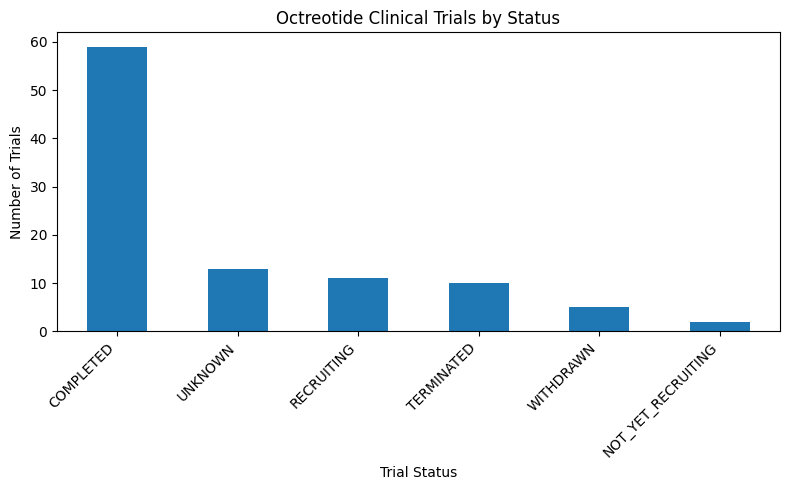

In [8]:
plt.figure(figsize=(8, 5))
status_counts.plot(kind="bar")
plt.title("Octreotide Clinical Trials by Status")
plt.xlabel("Trial Status")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Trial Status Interpretation

The status distribution provides a high-level view of the maturity of the octreotide clinical trial landscape.

A higher number of completed trials suggests that octreotide is a well-established therapeutic area with substantial historical clinical development activity. Recruiting and not-yet-recruiting studies indicate ongoing interest and continued investigation in selected indications or formulations.

> ## Phase distribution

In [9]:
phase_counts = df["phase"].fillna("MISSING").value_counts()

phase_counts

phase
PHASE2            33
MISSING           21
PHASE3            19
PHASE4            11
PHASE1             7
PHASE1, PHASE2     5
EARLY_PHASE1       2
PHASE2, PHASE3     2
Name: count, dtype: int64

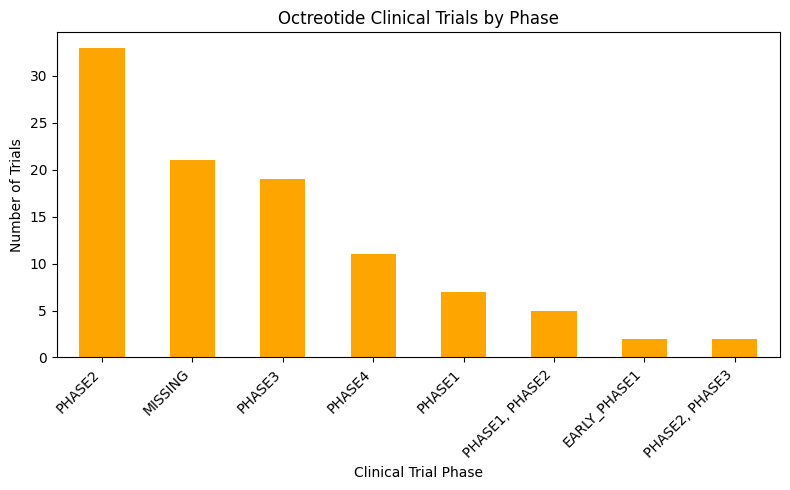

In [12]:
plt.figure(figsize=(8, 5))
phase_counts.plot(kind="bar", color="orange")
plt.title("Octreotide Clinical Trials by Phase")
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

> ## Start year trend

In [13]:
year_counts = (
    df["start_year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

year_counts

start_year
1995    1
1999    2
2002    6
2003    1
2004    2
2005    5
2006    8
2007    3
2008    5
2009    3
2010    1
2012    6
2013    7
2014    5
2015    2
2016    4
2017    1
2018    1
Name: count, dtype: int64

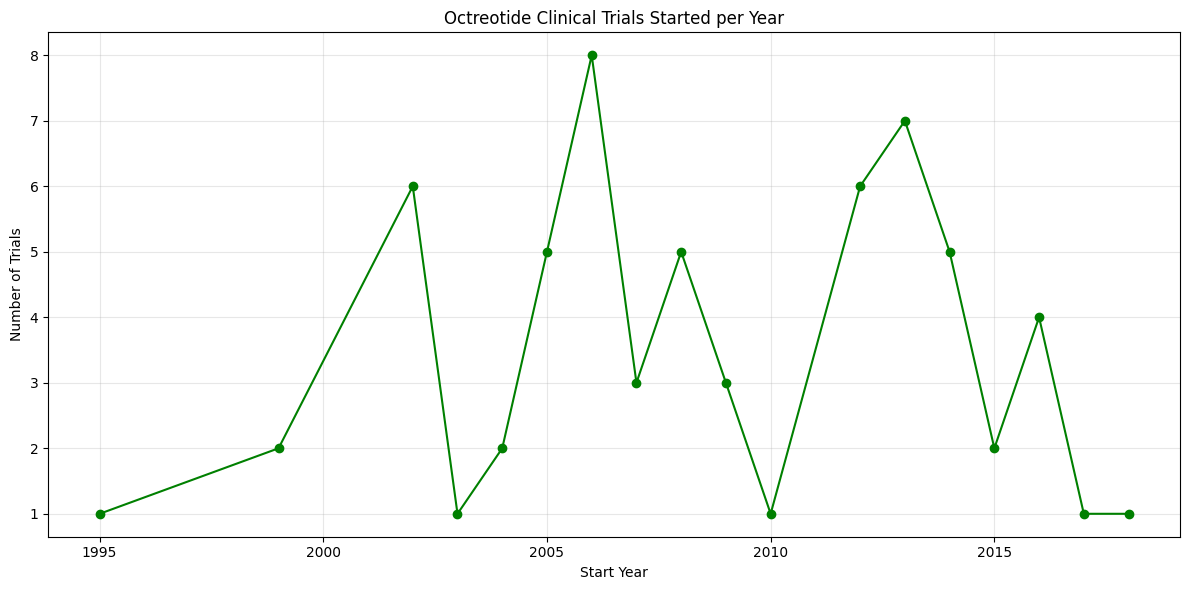

In [15]:
plt.figure(figsize=(12, 6))
year_counts.plot(kind="line", marker="o", color="green")
plt.title("Octreotide Clinical Trials Started per Year")
plt.xlabel("Start Year")
plt.ylabel("Number of Trials")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> ## Top sponsors

In [16]:
top_sponsors = df["sponsor"].value_counts().head(15)

top_sponsors

sponsor
Novartis                                                                      12
Ipsen                                                                          3
Radboud University Medical Center                                              2
University of Turin, Italy                                                     2
Lexicon Pharmaceuticals                                                        2
University of Aarhus                                                           2
University of Virginia                                                         2
Endo Pharmaceuticals                                                           2
Sue O'Dorisio                                                                  2
National Cancer Institute (NCI)                                                2
Federico II University                                                         2
Istituto Romagnolo per lo Studio dei Tumori Dino Amadori IRST S.r.l. IRCCS     2
Academisch Medisch C

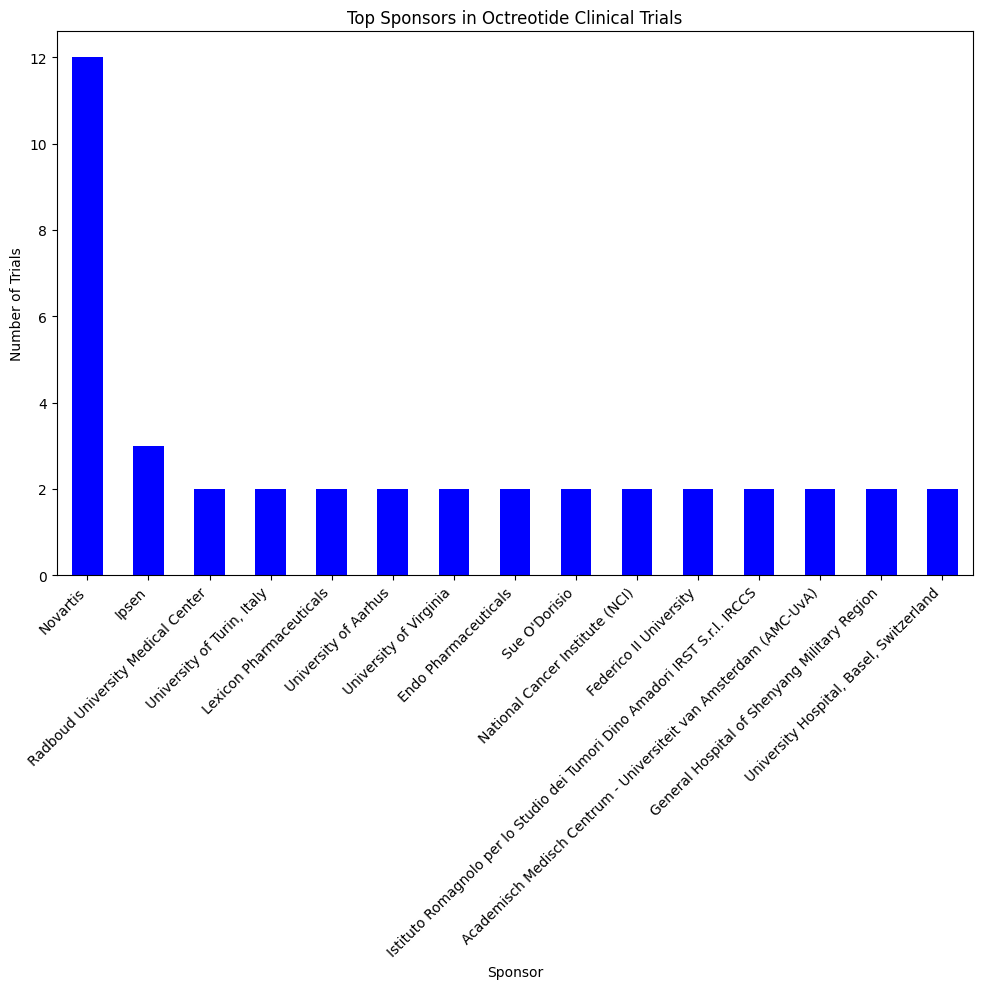

In [18]:
plt.figure(figsize=(10, 10))
top_sponsors.plot(kind="bar", color="blue")
plt.title("Top Sponsors in Octreotide Clinical Trials")
plt.xlabel("Sponsor")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

> ## Enrollment summary

In [19]:
df["enrollment"].describe()

count      99.000000
mean      135.818182
std       290.434487
min         0.000000
25%        22.000000
50%        45.000000
75%       123.500000
max      2000.000000
Name: enrollment, dtype: float64

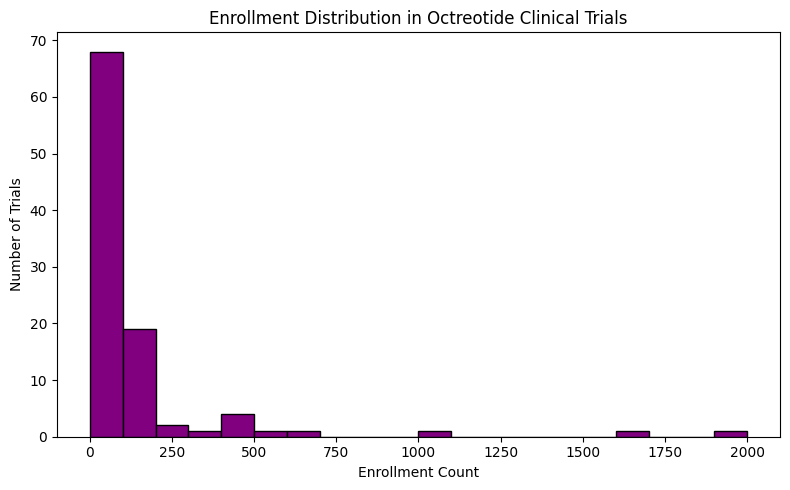

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df["enrollment"].dropna(), bins=20, color="purple", edgecolor="black")
plt.title("Enrollment Distribution in Octreotide Clinical Trials")
plt.xlabel("Enrollment Count")
plt.ylabel("Number of Trials")
plt.tight_layout()
plt.show()

> ## Trial duration summary

In [22]:
df["trial_duration_months"].describe()

count     51.000000
mean      47.582353
std       37.727585
min        0.000000
25%       23.500000
50%       40.000000
75%       63.450000
max      231.000000
Name: trial_duration_months, dtype: float64

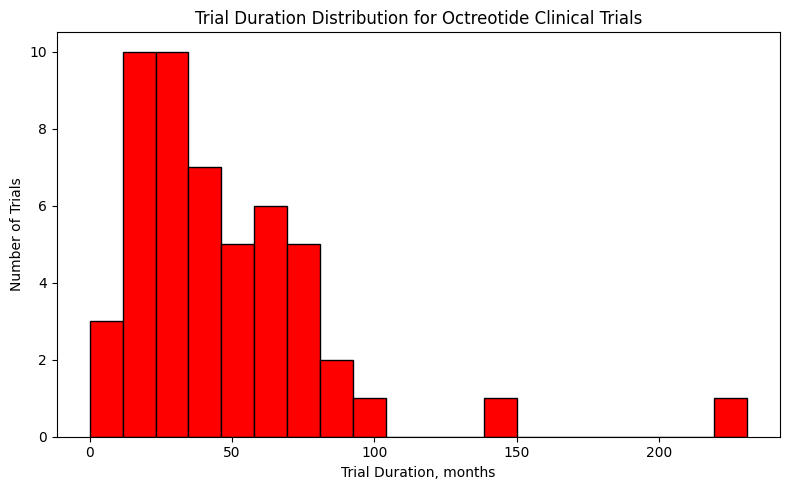

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(df["trial_duration_months"].dropna(), bins=20, color="red", edgecolor="black")
plt.title("Trial Duration Distribution for Octreotide Clinical Trials")
plt.xlabel("Trial Duration, months")
plt.ylabel("Number of Trials")
plt.tight_layout()
plt.show()

> ## Phase vs status table

In [32]:
phase_status_table = (
    pd.crosstab(
        df["phase"].fillna("MISSING"),
        df["status"].fillna("MISSING"),
        margins=True,
    )
    .sort_index(ascending=False)
)

phase_status_table

status,COMPLETED,NOT_YET_RECRUITING,RECRUITING,TERMINATED,UNKNOWN,WITHDRAWN,All
phase,,,,,,,
PHASE4,7,0,3,0,1,0,11
PHASE3,13,1,2,3,0,0,19
"PHASE2, PHASE3",2,0,0,0,0,0,2
PHASE2,20,1,2,3,4,3,33
"PHASE1, PHASE2",2,0,1,1,1,0,5
PHASE1,4,0,1,1,0,1,7
MISSING,10,0,1,2,7,1,21
EARLY_PHASE1,1,0,1,0,0,0,2
All,59,2,11,10,13,5,100


> ## Sponsor vs phase table

In [33]:
sponsor_phase_table = pd.crosstab(
    df["sponsor"],
    df["phase"].fillna("MISSING")
)

sponsor_phase_table.head(20)

phase,EARLY_PHASE1,MISSING,PHASE1,"PHASE1, PHASE2",PHASE2,"PHASE2, PHASE3",PHASE3,PHASE4
sponsor,,,,,,,,
Academisch Medisch Centrum - Universiteit van Amsterdam (AMC-UvA),0,1,0,0,0,0,0,1
Albert Einstein Healthcare Network,0,0,0,0,0,0,1,0
Alliance for Clinical Trials in Oncology,0,0,0,0,0,0,1,0
Anna Cruceta,0,0,0,0,1,0,0,0
Aspireo Pharmaceuticals Limited,0,0,1,0,0,0,0,0
Assistance Publique - Hôpitaux de Paris,0,0,0,0,0,0,1,0
Australasian Gastro-Intestinal Trials Group,0,0,0,0,1,0,0,0
Azienda USL Reggio Emilia - IRCCS,0,0,0,0,1,0,0,0
Boston Children's Hospital,0,0,0,0,0,0,0,1


>>> # **Portfolio summary metrics**

In [34]:
summary_metrics = pd.DataFrame({
    "Metric": [
        "Total trials",
        "Completed trials",
        "Recruiting trials",
        "Terminated trials",
        "Median enrollment",
        "Maximum enrollment",
        "Median trial duration, months",
        "Maximum trial duration, months"
    ],
    "Value": [
        len(df),
        (df["status"] == "COMPLETED").sum(),
        (df["status"] == "RECRUITING").sum(),
        (df["status"] == "TERMINATED").sum(),
        df["enrollment"].median(),
        df["enrollment"].max(),
        df["trial_duration_months"].median(),
        df["trial_duration_months"].max()
    ]
})

summary_metrics

,Metric,Value
0,Total trials,100.0
1,Completed trials,59.0
2,Recruiting trials,11.0
3,Terminated trials,10.0
4,Median enrollment,45.0
5,Maximum enrollment,2000.0
6,"Median trial duration, months",40.0
7,"Maximum trial duration, months",231.0


## **Key Insights**

This analysis shows that the octreotide clinical trial landscape is relatively mature, with a substantial number of completed studies.

The phase distribution indicates that octreotide has been evaluated across early-, mid-, and late-stage clinical development, with Phase 2 and Phase 3 studies forming an important part of the dataset.

Sponsor analysis highlights the main organisations involved in octreotide-related clinical development. Standardising sponsor names is important because the same organisation may appear under multiple names in ClinicalTrials.gov.

Enrollment and duration analysis suggest that trial burden varies substantially across studies, likely reflecting differences in indication, endpoint type, trial design, and recruitment requirements.

Overall, this notebook demonstrates how public clinical trial registry data can be transformed into a structured pharma data science analysis.